Best alpha: 88.58667904100822

=== Ridge Regression ===
Test samples: 150
MAE: 8.466636081190293
RMSE: 10.95171893086018


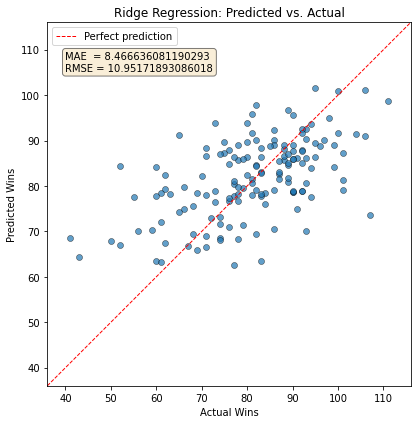

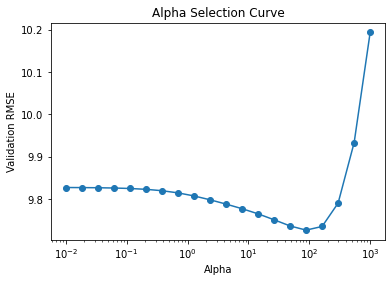


Top Features:
BB_prev: 2.136
HR_prev: 1.688
R_prev: 1.483
BBA_prev: -1.324
SOA_prev: 1.260
HRA_prev: -1.108
RA_prev: -1.091
ERA_prev: -1.063
H_prev: 0.997
HA_prev: -0.959


In [5]:
"""
Ridge Regression model for MLB win prediction.

Based on Lectures 6–7 (linear regression)
and Lecture 11 (regularization / generalization).
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

from data_pipeline import prepare_data, _REPO_ROOT, FEATURE_COLS
from evaluate import compute_mae, compute_rmse, plot_pred_vs_actual, print_metrics


def select_alpha(X, y, alphas, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    avg_rmse = []

    for alpha in alphas:
        rmses = []
        for train_idx, val_idx in kf.split(X):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            model = Ridge(alpha=alpha)
            model.fit(X_tr, y_tr)
            preds = model.predict(X_val)

            rmse = compute_rmse(y_val, preds)
            rmses.append(rmse)

        avg_rmse.append(np.mean(rmses))

    best_alpha = alphas[np.argmin(avg_rmse)]
    return best_alpha, avg_rmse


def fit_ridge(X_train, y_train, X_test, alpha):
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return model, preds



def run_ridge(csv_path=None):
    data = prepare_data(csv_path)

    X_train = data['X_train_scaled']
    y_train = data['y_train']
    X_test  = data['X_test_scaled']
    y_test  = data['y_test']

    # ---- select alpha ----
    alphas = np.logspace(-2, 3, 20)
    best_alpha, val_curve = select_alpha(X_train, y_train, alphas)

    print("Best alpha:", best_alpha)

    # ---- train final model ----
    model, predictions = fit_ridge(X_train, y_train, X_test, best_alpha)

    mae  = compute_mae(y_test, predictions)
    rmse = compute_rmse(y_test, predictions)

    return {
        'model': model,
        'predictions': predictions,
        'y_test': y_test,
        'mae': mae,
        'rmse': rmse,
        'alphas': alphas,
        'val_curve': val_curve,
        'feature_names': data['feature_names'],
        'coefficients': model.coef_,
        'test_df': data['test'],
    }



def plot_alpha_curve(alphas, errors):
    plt.figure()
    plt.semilogx(alphas, errors, marker='o')
    plt.xlabel("Alpha")
    plt.ylabel("Validation RMSE")
    plt.title("Alpha Selection Curve")
    plt.show()



def print_top_features(feature_names, coefs, top_n=10):
    idx = np.argsort(np.abs(coefs))[::-1][:top_n]
    print("\nTop Features:")
    for i in idx:
        print(f"{feature_names[i]}: {coefs[i]:.3f}")



if __name__ == '__main__':
    results = run_ridge()

    print("\n=== Ridge Regression ===")
    print("Test samples:", len(results['y_test']))
    print("MAE:", results['mae'])
    print("RMSE:", results['rmse'])

    # plot
    plot_pred_vs_actual(
        results['y_test'],
        results['predictions'],
        model_name='Ridge Regression',
        show=True
    )

    plot_alpha_curve(results['alphas'], results['val_curve'])

    print_top_features(results['feature_names'], results['coefficients'])